# Biološki informisana neuronska mreža za modelovanje rasta glioblastoma
---

Cilj projekta je implementacija BINN modela koji kombinuje neuronsku mrežu sa Gompertz diferencijalnom jednačinom za modelovanje dinamike rasta tumora na LUMIERE datasetu.

Model za svakog pacijenta uči tri biološka parametra:
  -  ***alpha*** - brzinu rasta tumora
  -  ***K***     - maksimalnu zapreminu ka kojoj tumor teži
  -  ***beta***  - efekat terapije (hemoterapija + radioterapija)

Jednačina modela:
    $$\frac{dV}{dt} = \alpha \cdot V \cdot \ln\left(\frac{K}{V}\right) - \beta \cdot V$$

Ovo nije standardna Gompoertz jednačina. Originalna jednačina ne sadrži parametar ***beta*** i modeluje isključivo spontani rast tumora. Pošto su pacijenti u LUMIERE datasetu primali hemoterapiju i radioterapiju tokom praćenja, dodat je parametar ***beta*** koji modeluje efekat terapije.

In [1]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

from models.binn import BINN
from training.binn_trainer import get_patient_data

CSV_PATH = "data/processed/tumor_volumes_clean.csv"
MODEL_PATH = "training/outputs/model.pt"
LOG_PATH = "training/outputs/training_log.csv"

HIDDEN_SIZE = 64
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

## Učitavanje podataka i modela

In [9]:
def tumor_grows(df, patient_id):
    patient_data = df[df['patient'] == patient_id].sort_values('week_normalized')
    first_volume = patient_data['volume_normalized'].iloc[0]
    last_volume = patient_data['volume_normalized'].iloc[-1]
    return last_volume > first_volume

df = pd.read_csv(CSV_PATH)
patients = df['patient'].unique()

model = BINN(hidden_size=HIDDEN_SIZE).to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE, weights_only=True))
model.eval()

print(f"Broj pacijenata: {len(patients)}")
print(f"Ukupno merenja: {len(df)}")

Broj pacijenata: 52
Ukupno merenja: 384


## Analiza bioloških parametara

Za svakog pacijenta model vraća ***alpha***, ***K***, ***beta*** zajedno sa ***MAE*** i ***MAPE*** (Mean Absolute Percentage Error) metrikom. Pacijenti su podeljeni u dve grupe u zavisnosti od toga da li tumor raste ili se smanjuje, na osnovu prve i poslednje izmerene zapremine

In [12]:
results = []

with torch.no_grad():
    for patient in patients:
        t, V, features = get_patient_data(df, patient)
        t = t.to(DEVICE)
        V = V.to(DEVICE)
        features = features.unsqueeze(0).to(DEVICE)

        V_pred, alpha, K, beta = model(features, t)
        V_pred = V_pred.squeeze()

        pred = V_pred.cpu().numpy()
        true = V.cpu().numpy()

        mae = np.mean(abs(pred - true))
        mask = true > 1e-6
        mape = np.mean(np.abs((pred[mask] - true[mask]) / true[mask])) * 100

        results.append({
            "patient":        patient,
            "alpha":          alpha.item(),
            "K":              K.item(),
            "beta":           beta.item(),
            "tumor_grows":    tumor_grows(df, patient),
            "mae":            mae,
            "mape":           mape,
            "initial_vol":    df[df['patient'] == patient]['initial_volume'].iloc[0],
            "n_measurements": len(true)
        })

    results_df = pd.DataFrame(results)
    results_df.to_csv("results/parameter_analysis.csv", index=False)

    print(f"Broj rastućih tumora: {results_df['tumor_grows'].sum()}")
    print(f"Broj tumora koji se smanjuju: {len(results_df[results_df['tumor_grows'] == False])}")

Broj rastućih tumora: 36
Broj tumora koji se smanjuju: 16


## Metrike modela

In [17]:
print(f"MAE  — Prosek: {results_df['mae'].mean():.4f} | Medijana: {results_df['mae'].median():.4f}")
print(f"MAPE — Prosek: {results_df['mape'].mean():.2f}% | Medijana: {results_df['mape'].median():.2f}%")

print("\nNajbolje predikcije (najmanji MAE):")
print(results_df.nsmallest(5, 'mae')[['patient', 'mae', 'mape', 'alpha', 'K', 'beta', 'tumor_grows']].round(3).to_string(index=False))

print("\nNajgore predikcije (najveći MAE):")
print(results_df.nlargest(5, 'mae')[['patient', 'mae', 'mape', 'alpha', 'K', 'beta', 'tumor_grows']].round(3).to_string(index=False))

MAE  — Prosek: 1.5214 | Medijana: 0.5227
MAPE — Prosek: 101.72% | Medijana: 57.20%

Najbolje predikcije (najmanji MAE):
    patient   mae      mape  alpha     K  beta  tumor_grows
Patient-086 0.181 15.290000  0.003 6.929 0.958        False
Patient-052 0.246 41.116001  0.018 7.906 0.923        False
Patient-004 0.259 53.060001  0.013 7.733 0.973        False
Patient-029 0.284 25.152000  0.271 9.147 0.270         True
Patient-028 0.313 59.299999  0.044 8.334 0.736        False

Najgore predikcije (najveći MAE):
    patient    mae      mape  alpha      K  beta  tumor_grows
Patient-015 13.604 53.941002 20.731 15.770 0.002         True
Patient-032  9.781 53.450001 23.560 17.272 0.001         True
Patient-007  8.484 45.606998 15.024 12.770 0.003         True
Patient-043  7.340 62.437000 12.385 11.304 0.004         True
Patient-040  3.549 47.570000  2.912 10.040 0.017         True


## Provera statističke relevantnosti dobijenih parametara

Mann-Whitney U test proverava da li se raspodela parametara statistički razlikuje izmedju grupe u kojoj tumori rastu od grupe u kojoj se tumori smanjuju. Korišćen je neparametarski test jer raspodele parametara ne prate normalnu raspodelu

In [18]:
grows = results_df[results_df['tumor_grows'] == True]
shrinks = results_df[results_df['tumor_grows'] == False]

for param in ['alpha', 'K', 'beta']:
    stat, p = stats.mannwhitneyu(grows[param].values, shrinks[param].values, alternative='two-sided')
    print(f"{param:6s} | p = {p:.6f} | {'značajno' if p < 0.05 else 'nije značajno'}")

alpha  | p = 0.000002 | značajno
K      | p = 0.000003 | značajno
beta   | p = 0.000002 | značajno


## Tok treniranja

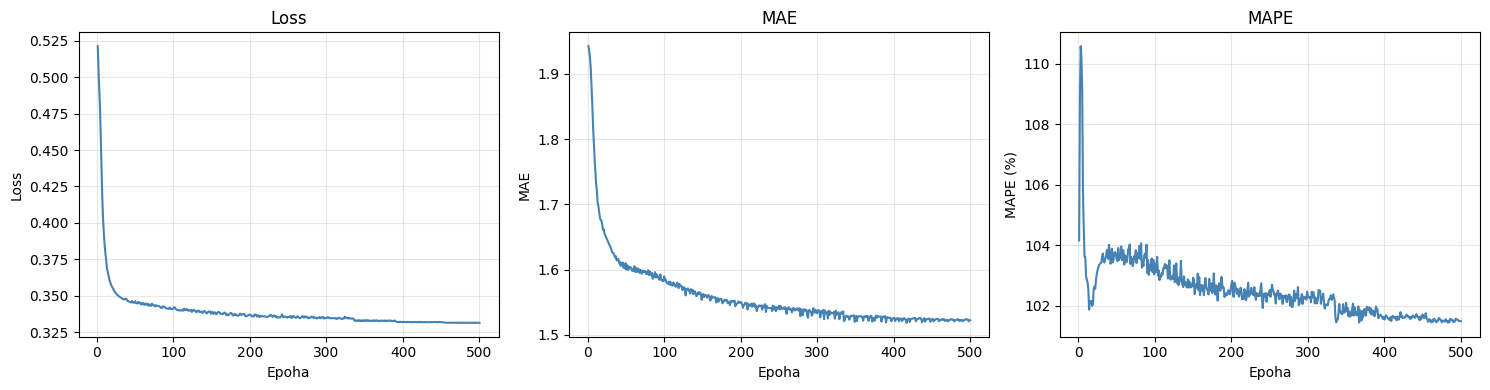

In [19]:
log = pd.read_csv(LOG_PATH)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(log['epoch'], log['train_loss'], color='steelblue')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoha')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(log['epoch'], log['train_mae'], color='steelblue')
axes[1].set_title('MAE')
axes[1].set_xlabel('Epoha')
axes[1].set_ylabel('MAE')
axes[1].grid(True, alpha=0.3)

axes[2].plot(log['epoch'], log['train_mape'], color='steelblue')
axes[2].set_title('MAPE')
axes[2].set_xlabel('Epoha')
axes[2].set_ylabel('MAPE (%)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

***Loss*** i ***MAE*** opadaju tokom svih 500 epoha, što govori da model uči i konvergira. ***MAPE*** osciluje i stabilizuje se oko 102%, što je visoko ali i očekivano. Neki pacijenti imaju tumor koji naraste i do 70 puta početne zapremine što je teško predstaviti Gompertz krivom.

## Razlika izmedju parametara za rastuće i smanjujuće tumore

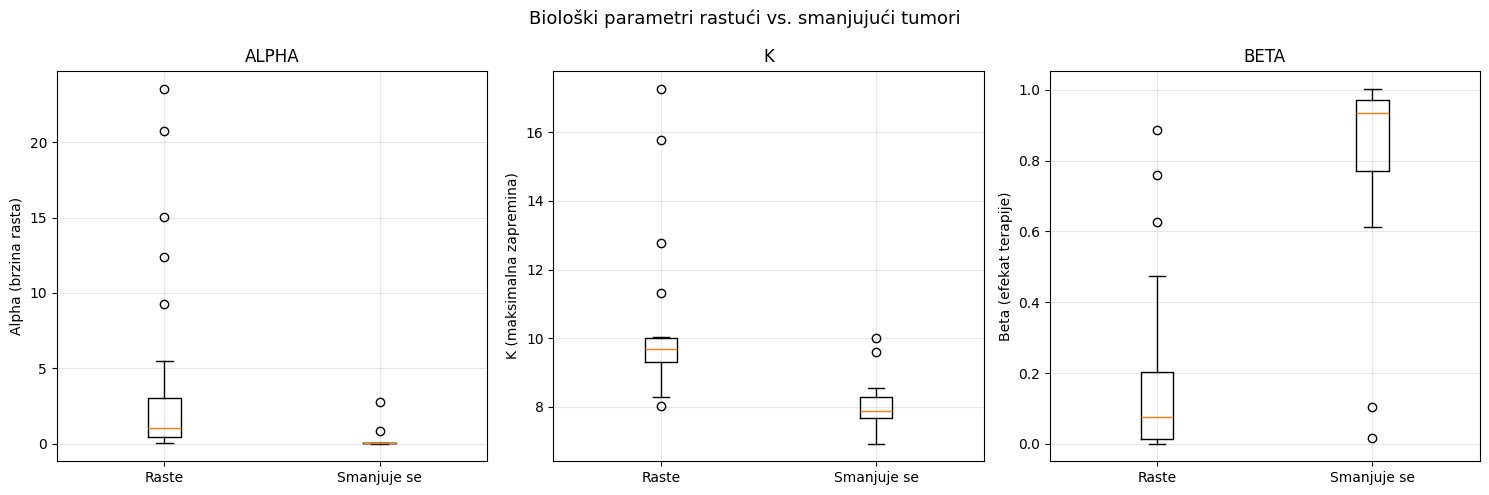

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

params = [
    ('alpha', 'Alpha (brzina rasta)'),
    ('K',     'K (maksimalna zapremina)'),
    ('beta',  'Beta (efekat terapije)')
]

for i, (param, label) in enumerate(params):
    axes[i].boxplot(
        [grows[param].values, shrinks[param].values],
        tick_labels=['Raste', 'Smanjuje se']
    )
    axes[i].set_title(param.upper())
    axes[i].set_ylabel(label)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Biološki parametri rastući vs. smanjujući tumori', fontsize=13)
plt.tight_layout()
plt.savefig('results/parameter_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

***Alpha*** je očekivano veći kod rastućih tumora, ali ima dosta outlier'a sa vrednostima iznad 15, što je van biološki realnog opsega. To su pacijenti sa izuzetno agresivnim tumorima koje model ne uspeva dobro da predstavi.

Kod rastućih tumora medijalna vrednost parametra ***K*** je oko 9.7, dok je kod tumora koji se smanjuju oko 7.9. Intuitivno ima smisla, ako terapija ne deluje (malo beta), tumor slobodno raste i model mu dodeljuje veći ***K***. Kod pacijenata kod kojih terapija deluje, tumor se smanjuje pa i model procenjuje da je i maksimalni kapacitet tumora bio manji od početka.

Kod pacijenata čiji se tumor smanjuje, medijalna vrednost parametra ***beta*** je oko 0.935, dok je kod rastućih svega 0.077, što je razlika od skoro 12 puta. Ovo, takodje, intuitivno ima smila jer visoko
***beta*** znači da terapija efikasno ubija ćelije tumora.

## Predikcije

3 najbolje i 3 najgore predikcije rangirane po MAE metrici.

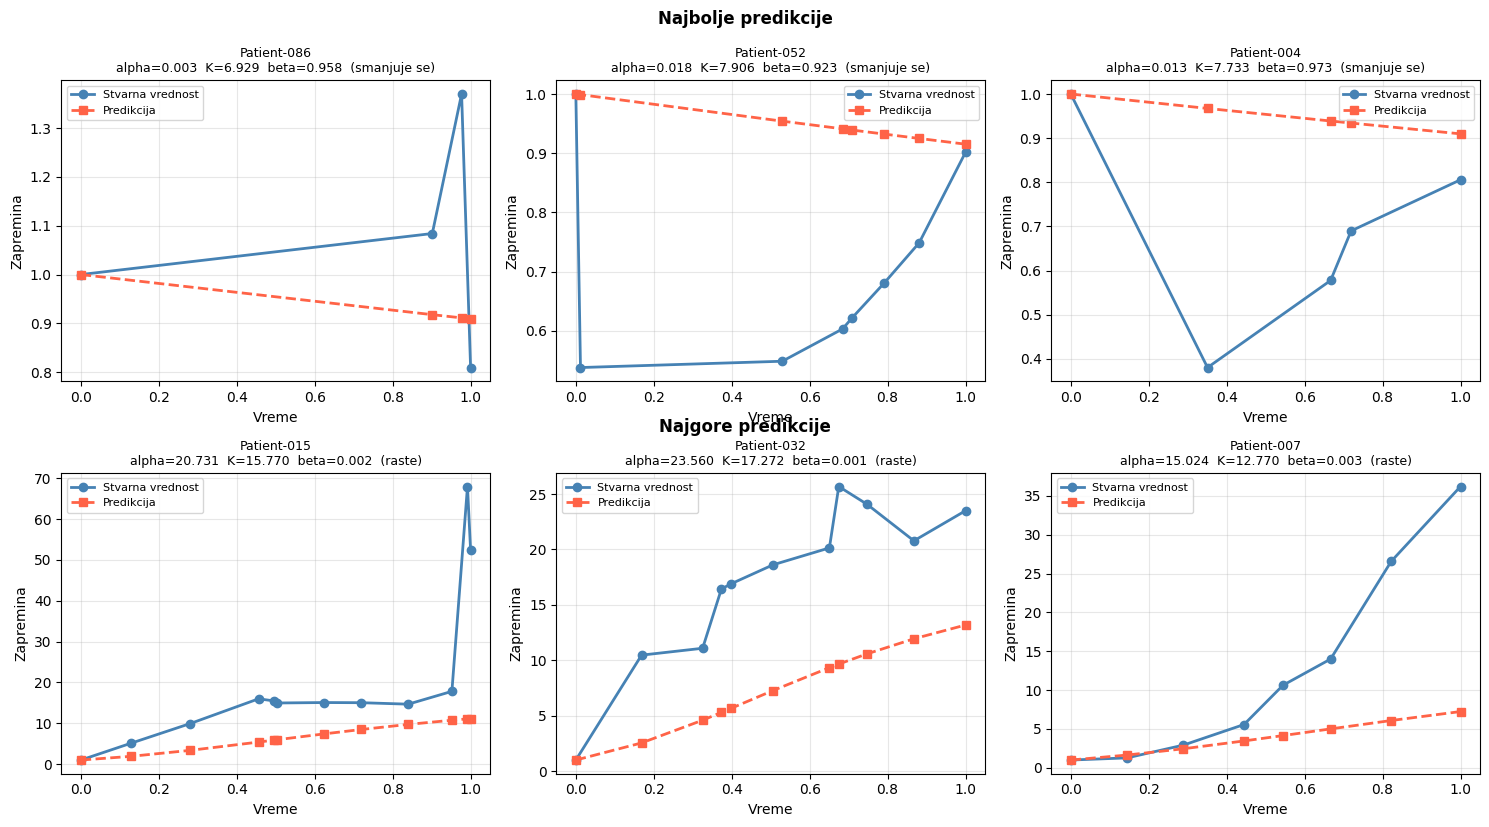

In [21]:
best_patients = results_df.nsmallest(3, 'mae')['patient'].tolist()
worst_patients = results_df.nlargest(3, 'mae')['patient'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

with torch.no_grad():
    for i, patient_id in enumerate(best_patients + worst_patients):
        t, V, features = get_patient_data(df, patient_id)
        t = t.to(DEVICE)
        features = features.unsqueeze(0).to(DEVICE)

        V_pred, alpha, K, beta = model(features, t)
        V_pred = V_pred.squeeze().cpu().numpy()
        V_true = V.numpy()
        t_np = t.cpu().numpy()

        row = results_df[results_df['patient'] == patient_id].iloc[0]
        status = "raste" if row['tumor_grows'] else "smanjuje se"

        axes[i].plot(t_np, V_true, 'o-',  label='Stvarna vrednost',    color='steelblue', linewidth=2)
        axes[i].plot(t_np, V_pred, 's--', label='Predikcija', color='tomato',    linewidth=2)
        axes[i].set_title(
            f"{patient_id}\n"
            f"alpha={alpha.item():.3f}  K={K.item():.3f}  beta={beta.item():.3f}  ({status})",
            fontsize=9
        )
        axes[i].set_xlabel('Vreme')
        axes[i].set_ylabel('Zapremina')
        axes[i].legend(fontsize=8)
        axes[i].grid(True, alpha=0.3)

    fig.text(0.5, 1.01, 'Najbolje predikcije', ha='center', fontsize=12, fontweight='bold')
fig.text(0.5, 0.5,  'Najgore predikcije',  ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('results/predictions.png', dpi=150, bbox_inches='tight')
plt.show()

## Raspodela parametara po svim pacijentima

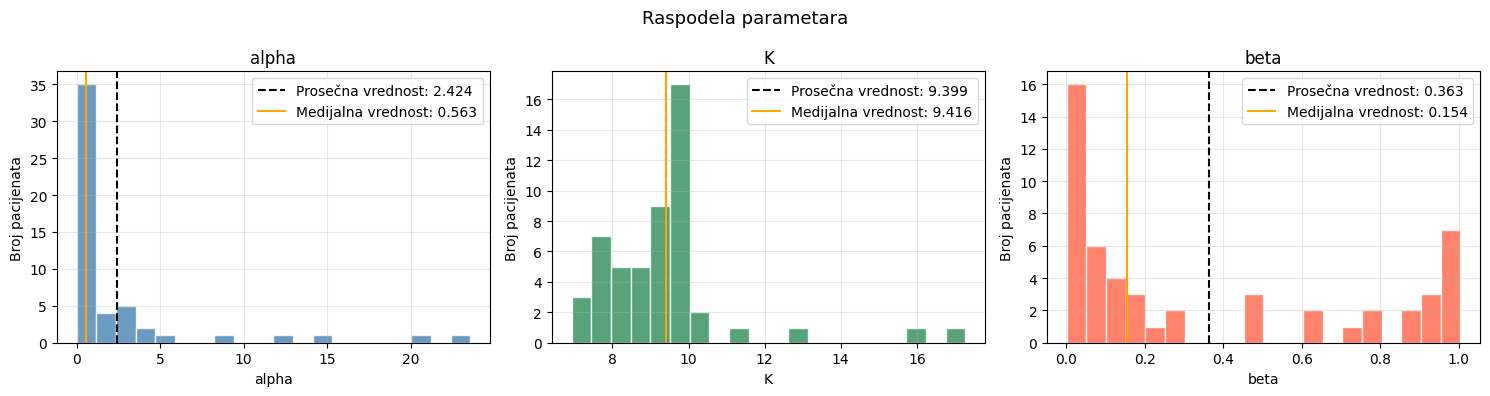

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

params = [
    ('alpha', 'steelblue'),
    ('K',     'seagreen'),
    ('beta',  'tomato'),
]

for ax, (param, color) in zip(axes, params):
    ax.hist(results_df[param], bins=20, color=color, edgecolor='white', alpha=0.8)
    ax.axvline(results_df[param].mean(),   color='black', linestyle='--',
               label=f'Prosečna vrednost: {results_df[param].mean():.3f}')
    ax.axvline(results_df[param].median(), color='orange', linestyle='-',
               label=f'Medijalna vrednost: {results_df[param].median():.3f}')
    ax.set_title(param)
    ax.set_xlabel(param)
    ax.set_ylabel('Broj pacijenata')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Raspodela parametara', fontsize=13)
plt.tight_layout()
plt.savefig('results/parameter_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

Raspodela ***alpha*** je asimetrična, skoro 35 od 52 pacijenata ima ***alpha*** ispod 1, dok nekoliko pacijenata ima vrednost izmedju 15 i 23. Prosečna vrednost je daleko od medijalne, upravo zbog ti outlier-a.

Raspodela parametra ***K*** je koncentrisana oko 9-10, što je direktna posledica "biology penal" koji kažnjava vrednosti iznad 10. Prosek i medijana su skoro identični, što znači da nema značajnih outlier-a i da je ovo jedini parametar kome raspodela teži ka normalnoj raspodeli.

Kod raspodele parametra ***beta*** jasno postoje dve jasne grupe pacijenata. Jedna grupa ima ***beta*** vrednost blizu nule (terapija ne deluje), dok druga ima ***beta*** vrednost blizu 1 (terapija efikasno smanjuje tumor). Prosek i medijana su dosta različiti jer ih vuče manja grupa pacijenata sa visokim vrednostima. Ova bimodalnost dobro odražava kliničku realnost jer kod nekih pacijenata terapija deluje, dok kod nekih ne.


Model uspešno uči tri biološka parametra koji se statistički značajno razlikuju između rastućih i smanjujućih tumora (p < 0.00001 za sva tri parametra).

Najbitniji nalaz je da beta, parametar koji je dodat kao proširenje standardne Gompertz jednačine, pokazuje najveću razliku između grupa. Medijana je 12x veća kod pacijenata čiji se tumor smanjuje (0.935 i 0.077). Ovo direktno znači da model razlikuje pacijente koji reaguju na terapiju od onih koji ne reaguju.

Najveći problem modela su pacijenti sa ekstremno agresivnim tumorima koji narastu i do 70x početne zapremine. Gompertz jednačina sa konstantnim parametrima matematički nije u stanju da prati takvu dinamiku, pa su te predikcije daleko od stvarnih vrednosti i dižu prosečnu MAE grešku.